In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load dataset (Handle encoding issues common with this specific CSV)
try:
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
except FileNotFoundError:
    print("Please upload 'Sample - Superstore.csv' to your Colab directory!")

# Inspect the dataset
print(f"Dataset Shape: {df.shape}")
df.head(3)

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Convert Date columns to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract Year-Month for trend analysis
df['Year_Month'] = df['Order Date'].dt.to_period('M')

print("\nData preprocessing complete. Date columns successfully parsed!")

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data preprocessing complete. Date columns successfully parsed!


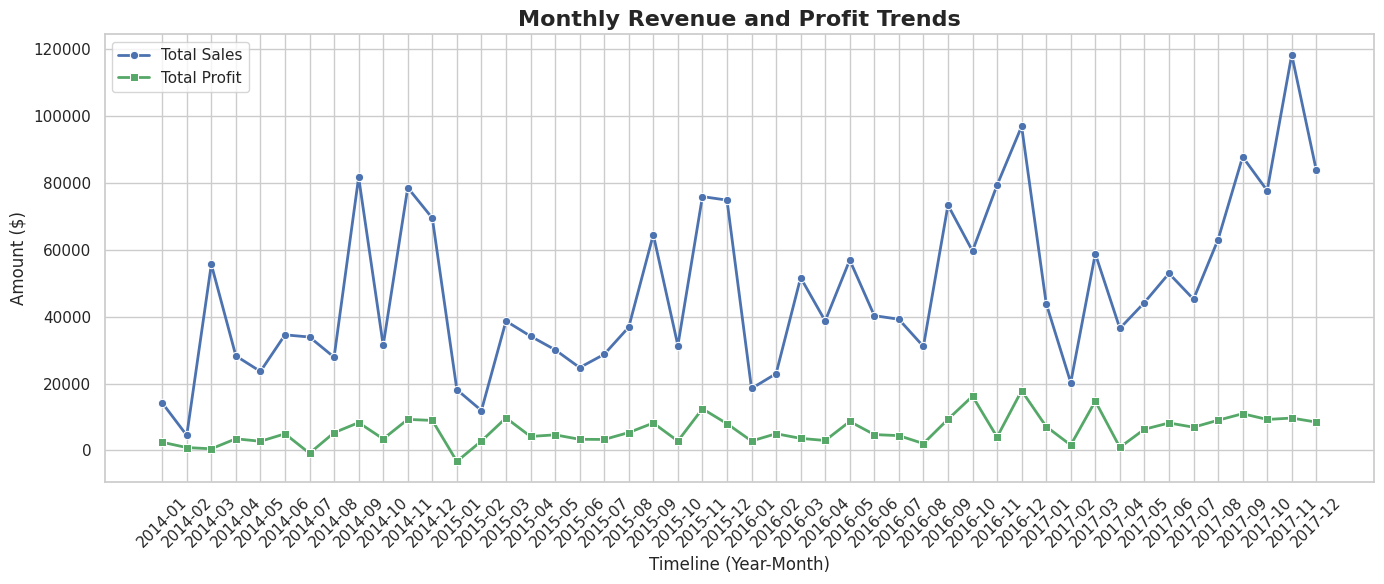

In [5]:
# Group by Year_Month to calculate total sales and profit
monthly_trends = df.groupby('Year_Month').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
monthly_trends['Year_Month'] = monthly_trends['Year_Month'].astype(str) # Convert to string for plotting

# Plotting Monthly Revenue
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trends, x='Year_Month', y='Sales', marker='o', label='Total Sales', color='b', linewidth=2)
sns.lineplot(data=monthly_trends, x='Year_Month', y='Profit', marker='s', label='Total Profit', color='g', linewidth=2)

plt.xticks(rotation=45)
plt.title('Monthly Revenue and Profit Trends', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_3003/1809130621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Sales', y='Product Name', palette='Blues_r')


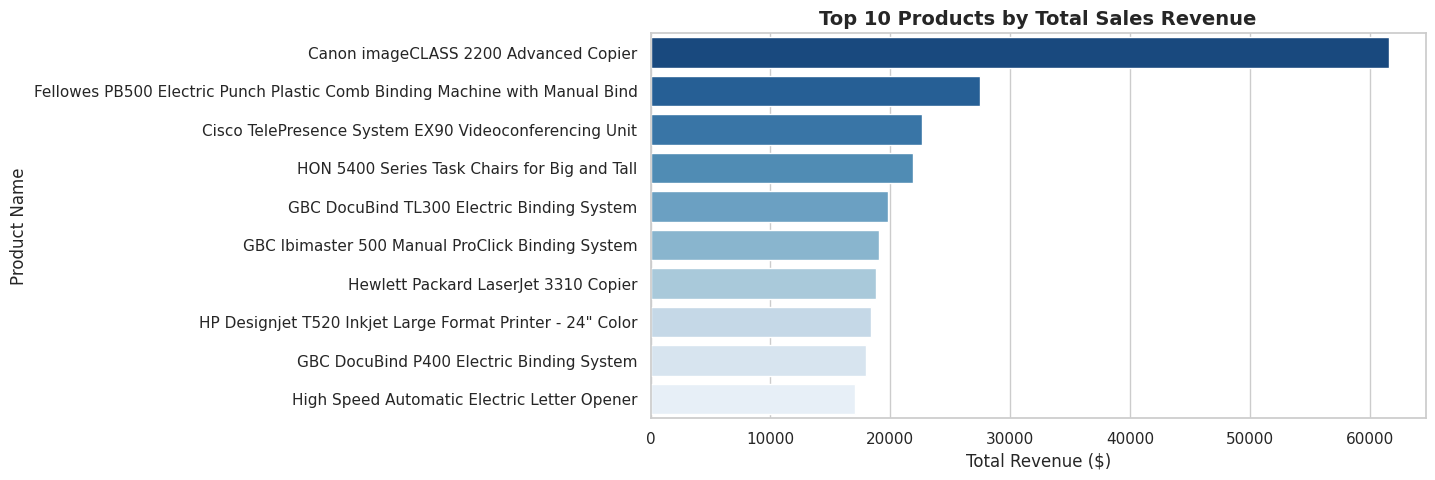


--- Category Breakdown ---
          Category        Sales       Profit
0        Furniture  741999.7953   18451.2728
1  Office Supplies  719047.0320  122490.8008
2       Technology  836154.0330  145454.9481


In [6]:
# Top 10 Selling Products by Revenue
top_products = df.groupby('Product Name')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x='Sales', y='Product Name', palette='Blues_r')
plt.title('Top 10 Products by Total Sales Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Name')
plt.show()

# Category Performance
category_perf = df.groupby('Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
print("\n--- Category Breakdown ---")
print(category_perf)

/tmp/ipykernel_3003/4218937039.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_profit, x='Sub-Category', y='Profit', palette='RdYlGn')


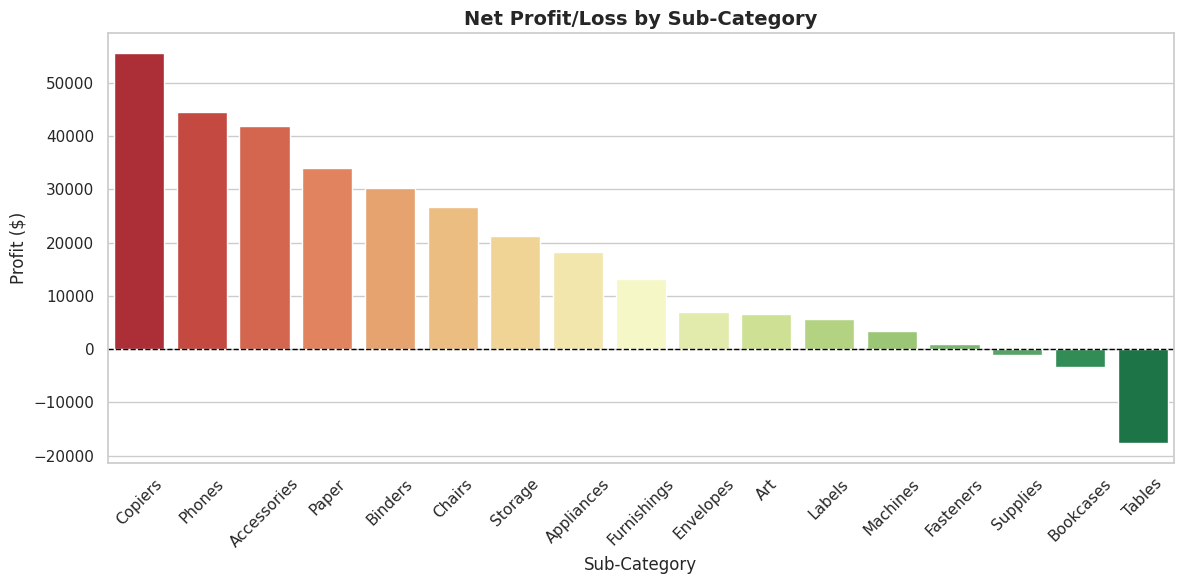

In [7]:
# Aggregate profit across different Sub-Categories
sub_cat_profit = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index().sort_values(by='Profit', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=sub_cat_profit, x='Sub-Category', y='Profit', palette='RdYlGn')
plt.xticks(rotation=45)
plt.title('Net Profit/Loss by Sub-Category', fontsize=14, fontweight='bold')
plt.ylabel('Profit ($)')
plt.xlabel('Sub-Category')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Baseline at $0
plt.tight_layout()
plt.show()

In [9]:
# Identify unprofitable states
bleeding_states = df.groupby('State')['Profit'].sum().reset_index().sort_values(by='Profit').head(5)
print(" Top 5 Unprofitable States (Bleeding Cash):")
print(bleeding_states.to_string(index=False))

# Identify unprofitable sub-categories
bleeding_products = df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values(by='Profit').head(3)
print("\n Top 3 Loss-Making Sub-Categories:")
print(bleeding_products.to_string(index=False))

 Top 5 Unprofitable States (Bleeding Cash):
         State      Profit
         Texas -25729.3563
          Ohio -16971.3766
  Pennsylvania -15559.9603
      Illinois -12607.8870
North Carolina  -7490.9122

 Top 3 Loss-Making Sub-Categories:
Sub-Category      Profit
      Tables -17725.4811
   Bookcases  -3472.5560
    Supplies  -1189.0995
